In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8")
%matplotlib inline

CSV_PATH = Path("benchmark_results.csv")
MATRICES_PATH = Path("last_run_matrices.json")

In [9]:
expected_columns = [
    "rows_a",
    "cols_a",
    "cols_b",
    "serial_time_ms",
    "parallel_time_ms",
    "speedup",
    "num_servers",
    "timestamp",
]

if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {CSV_PATH.resolve()}"
    )

df = pd.read_csv(CSV_PATH)

missing = set(expected_columns) - set(df.columns)

if missing:
    raise ValueError(
        f"O CSV não possui as colunas esperadas: {sorted(missing)}"
    )

df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce",
)

df = df.sort_values(
    [
        "rows_a",
        "cols_a",
        "cols_b",
        "timestamp",
    ]
).reset_index(drop=True)

df

,rows_a,cols_a,cols_b,serial_time_ms,parallel_time_ms,speedup,num_servers,timestamp
0,20,10,30,0.04,2057.77,0.00,2,2026-05-16 11:27:06
1,50,25,60,0.10,2064.14,0.00,2,2026-05-16 11:27:08
2,100,50,120,0.41,2026.19,0.00,2,2026-05-16 11:27:10
3,200,100,250,4.77,2077.25,0.00,2,2026-05-16 11:27:12
4,1000,2000,1000,1634.81,3369.81,0.49,2,2026-05-16 11:27:18
5,2000,3000,2000,60201.77,18421.79,3.27,2,2026-05-16 11:28:36


In [14]:
summary = (
    df.groupby(
        [
            "rows_a",
            "cols_a",
            "cols_b",
        ]
    )
    .agg(
        serial_time_ms=("serial_time_ms", "mean"),
        parallel_time_ms=("parallel_time_ms", "mean"),
        speedup=("speedup", "mean"),
    )
    .reset_index()
)

summary

,rows_a,cols_a,cols_b,serial_time_ms,parallel_time_ms,speedup
0,20,10,30,0.04,2057.77,0.00
1,50,25,60,0.10,2064.14,0.00
2,100,50,120,0.41,2026.19,0.00
3,200,100,250,4.77,2077.25,0.00
4,1000,2000,1000,1634.81,3369.81,0.49
5,2000,3000,2000,60201.77,18421.79,3.27


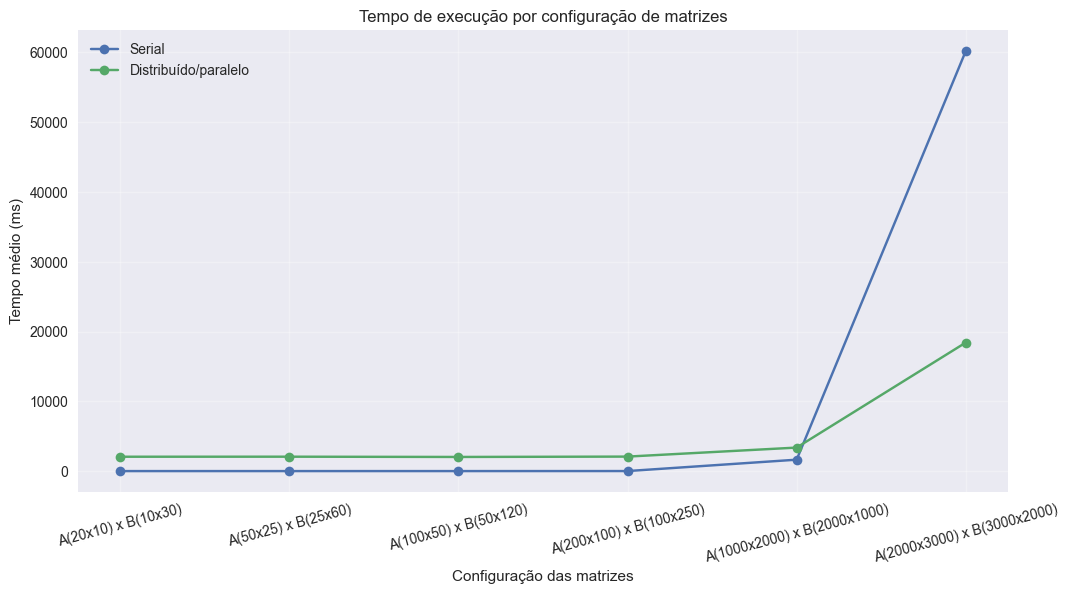

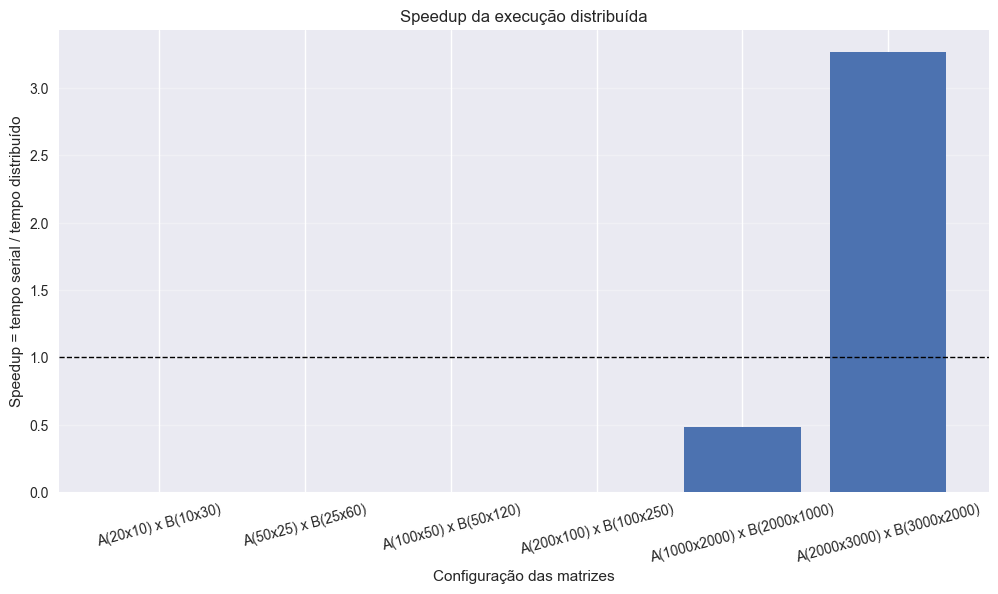

In [11]:
if summary.empty:

    print("Sem dados para plotar.")

else:

    labels = [
        f"A({r}x{c}) x B({c}x{p})"
        for r, c, p in zip(
            summary["rows_a"],
            summary["cols_a"],
            summary["cols_b"],
        )
    ]

    # -----------------------------
    # Gráfico de tempo
    # -----------------------------

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(
        labels,
        summary["serial_time_ms"],
        marker="o",
        label="Serial",
    )

    ax.plot(
        labels,
        summary["parallel_time_ms"],
        marker="o",
        label="Distribuído/paralelo",
    )

    ax.set_title(
        "Tempo de execução por configuração de matrizes"
    )

    ax.set_xlabel("Configuração das matrizes")

    ax.set_ylabel("Tempo médio (ms)")

    ax.legend()

    ax.grid(True, alpha=0.3)

    plt.xticks(rotation=15)

    plt.show()

    # -----------------------------
    # Gráfico de speedup
    # -----------------------------

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.bar(labels, summary["speedup"])

    ax.axhline(
        1,
        color="black",
        linewidth=1,
        linestyle="--",
    )

    ax.set_title(
        "Speedup da execução distribuída"
    )

    ax.set_xlabel("Configuração das matrizes")

    ax.set_ylabel(
        "Speedup = tempo serial / tempo distribuído"
    )

    ax.grid(True, axis="y", alpha=0.3)

    plt.xticks(rotation=15)

    plt.show()

In [16]:
labels = [
    f"A({r}x{c}) B({c}x{p})"
    for r, c, p in zip(
        summary["rows_a"],
        summary["cols_a"],
        summary["cols_b"],
    )
]

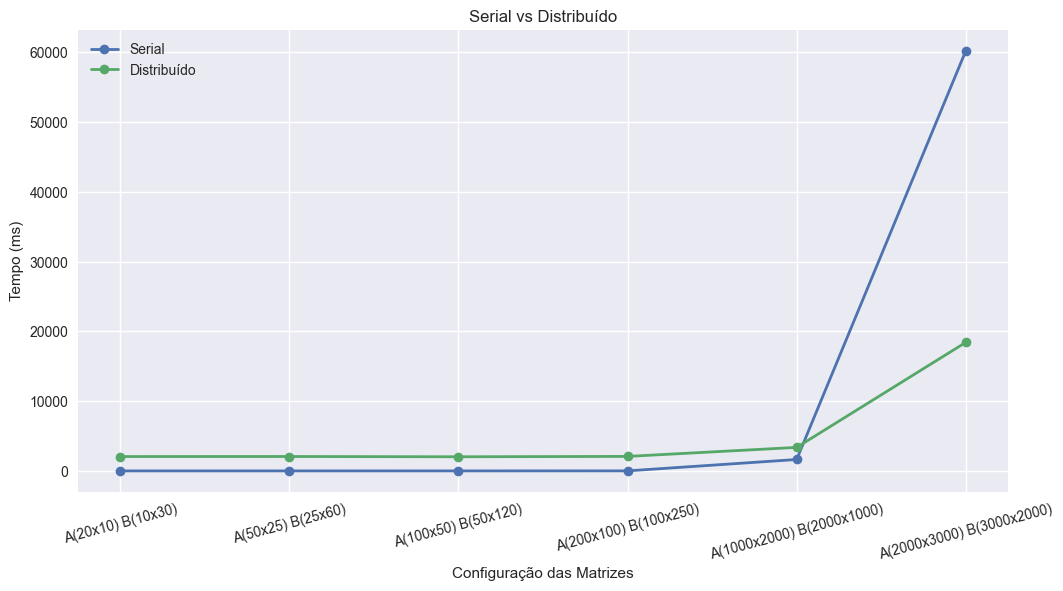

In [17]:
plt.figure(figsize=(12, 6))

plt.plot(
    labels,
    summary["serial_time_ms"],
    marker="o",
    linewidth=2,
    label="Serial",
)

plt.plot(
    labels,
    summary["parallel_time_ms"],
    marker="o",
    linewidth=2,
    label="Distribuído",
)

plt.xlabel("Configuração das Matrizes")
plt.ylabel("Tempo (ms)")
plt.title("Serial vs Distribuído")

plt.xticks(rotation=15)

plt.grid(True)
plt.legend()

plt.show()

In [20]:
def preview_matrix(matrix_data, rows=5, cols=5):

    matrix = np.array(matrix_data)

    return matrix[:rows, :cols]


if not MATRICES_PATH.exists():

    print(
        "Arquivo last_run_matrices.json não encontrado. "
        "Execute o Client.py primeiro."
    )

else:

    with MATRICES_PATH.open(
        "r",
        encoding="utf-8",
    ) as json_file:

        last_run = json.load(json_file)

    print(
        f"Última execução: "
        f"{last_run.get('timestamp', 'sem timestamp')}"
    )

    print(
        f"Servidores: "
        f"{', '.join(last_run.get('servers', []))}\n"
    )

    matrices = last_run.get("matrices", {})

    for matrix_key in matrices:

        item = matrices[matrix_key]

        rows_a = item["rows_a"]
        cols_a = item["cols_a"]
        cols_b = item["cols_b"]

        print(
            f"A({rows_a}x{cols_a}) "
            f"x "
            f"B({cols_a}x{cols_b})"
        )

        print()

        print("  Matriz A (primeiras 5x5):")

        print(
            preview_matrix(item["A"])
        )

        print()

        print("  Matriz B (primeiras 5x5):")

        print(
            preview_matrix(item["B"])
        )

        print()

        for partial in item.get(
            "partial_results",
            [],
        ):

            server_number = partial.get(
                "server",
                "?",
            )

            rows = partial.get(
                "rows",
                "?",
            )

            cols = partial.get(
                "cols",
                "?",
            )

            print(
                f"  Resultado parcial do "
                f"Servidor {server_number} "
                f"({rows}x{cols}) "
                f"- primeiras 5x5:"
            )

            print(
                preview_matrix(
                    partial["matrix"]
                )
            )

            print()

        print(
            "  Matriz C final "
            "(primeiras 5x5):"
        )

        print(
            preview_matrix(item["C"])
        )

        print()

Última execução: 2026-05-16 11:23:10
Servidores: localhost:5000, localhost:5001

A(20x10) x B(10x30)

  Matriz A (primeiras 5x5):
[[4 6 7 2 6]
 [5 2 5 2 8]
 [5 8 9 5 5]
 [5 3 7 5 9]
 [9 9 6 2 4]]

  Matriz B (primeiras 5x5):
[[3 8 7 4 7]
 [9 4 3 1 8]
 [9 1 8 5 6]
 [2 6 1 6 5]
 [4 4 8 2 1]]

  Resultado parcial do Servidor 1 (10x30) - primeiras 5x5:
[[236 185 214 153 182]
 [154 144 198 133 115]
 [333 249 297 245 234]
 [230 219 247 201 183]
 [325 270 299 247 244]]

  Resultado parcial do Servidor 2 (10x30) - primeiras 5x5:
[[283 278 274 251 210]
 [258 302 282 285 203]
 [302 314 284 273 260]
 [255 175 244 167 160]
 [230 217 265 206 171]]

  Matriz C final (primeiras 5x5):
[[236 185 214 153 182]
 [154 144 198 133 115]
 [333 249 297 245 234]
 [230 219 247 201 183]
 [325 270 299 247 244]]

A(50x25) x B(25x60)

  Matriz A (primeiras 5x5):
[[3 6 1 9 4]
 [5 5 7 5 5]
 [4 8 2 9 5]
 [7 9 5 1 8]
 [9 8 5 9 6]]

  Matriz B (primeiras 5x5):
[[1 6 6 5 1]
 [9 5 9 6 3]
 [8 1 2 2 1]
 [7 5 7 3 1]
 [2 6 9 7

In [23]:
if summary.empty:

    print(
        "Ainda não há resultados para analisar."
    )

else:

    for row in summary.itertuples(index=False):

        print(
            f"A({int(row.rows_a)}x{int(row.cols_a)}) "
            f"x "
            f"B({int(row.cols_a)}x{int(row.cols_b)}) "
            f"com "
           # f"{int(row.num_servers)} servidores: "
            f"serial={row.serial_time_ms:.2f} ms, "
            f"distribuído={row.parallel_time_ms:.2f} ms, "
            f"speedup={row.speedup:.2f}x "
          #  f"({int(row.runs)} execução/execuções)."
        )

    best = summary.loc[
        summary["speedup"].idxmax()
    ]

    print()

    print(
        "Melhor speedup observado: "
        f"{best['speedup']:.2f}x "
        f"para "
        f"A({int(best['rows_a'])}x{int(best['cols_a'])}) "
        f"x "
        f"B({int(best['cols_a'])}x{int(best['cols_b'])})."
    )

A(20x10) x B(10x30) com serial=0.04 ms, distribuído=2057.77 ms, speedup=0.00x 
A(50x25) x B(25x60) com serial=0.10 ms, distribuído=2064.14 ms, speedup=0.00x 
A(100x50) x B(50x120) com serial=0.41 ms, distribuído=2026.19 ms, speedup=0.00x 
A(200x100) x B(100x250) com serial=4.77 ms, distribuído=2077.25 ms, speedup=0.00x 
A(1000x2000) x B(2000x1000) com serial=1634.81 ms, distribuído=3369.81 ms, speedup=0.49x 
A(2000x3000) x B(3000x2000) com serial=60201.77 ms, distribuído=18421.79 ms, speedup=3.27x 

Melhor speedup observado: 3.27x para A(2000x3000) x B(3000x2000).
